In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

# copied from claire's notebook

In [ ]:
df = pd.read_csv('data/ads.csv')
df.head()

,id,ad_creation_time,ad_delivery_start_time,bylines,currency,page_id,page_name,ad_creative_bodies,ad_creative_link_captions,ad_creative_link_descriptions,...,45-54/unknown,55-64/female,55-64/male,55-64/unknown,65+/female,65+/male,65+/unknown,Unknown/female,Unknown/male,Unknown/unknown
0,1263237120532732,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,Cancel Culture is killing intellectual convers...,youtu.be,NaN,...,0.02,0.97,1.22,0.01,0.94,0.80,0.01,0.0,0.0,0.0
1,2508232389430627,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,On this week's episode we are joined by Bret S...,youtu.be,NaN,...,0.02,2.56,5.44,0.06,3.05,3.22,0.04,0.0,0.0,0.0
2,156182708989204,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.11,19.13,19.85,0.25,20.26,12.40,0.25,0.0,0.0,0.0
3,397644197860634,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.11,19.72,19.94,0.25,18.27,10.68,0.25,0.0,0.0,0.0
4,527071631288361,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.11,18.72,21.20,0.28,14.66,10.20,0.22,0.0,0.0,0.0


In [ ]:
buzz_df = df.copy()

buzz_df['year'] = pd.to_datetime(buzz_df['ad_creation_time']).dt.year
buzz_df = buzz_df[buzz_df['ad_creative_bodies'].notna()]

buzz_df['clean_text'] = buzz_df['ad_creative_bodies'].str.lower()

demo_cols = [col for col in buzz_df.columns if '/' in col]
demo_cols = [col for col in demo_cols if not col.startswith('Unknown/')]

age_ranges = sorted(set(col.split('/')[0] for col in demo_cols))
genders = sorted(set(col.split('/')[1] for col in demo_cols))

# age totals
for age in age_ranges:
    age_specific_cols = [col for col in demo_cols if col.startswith(age + '/')]
    buzz_df[f'age_{age}_total'] = buzz_df[age_specific_cols].sum(axis=1)

age_total_cols = [f'age_{age}_total' for age in age_ranges]

# gender totals
for gender in genders:
    gender_specific_cols = [col for col in demo_cols if col.endswith('/' + gender)]
    buzz_df[f'gender_{gender}_total'] = buzz_df[gender_specific_cols].sum(axis=1)

gender_total_cols = [f'gender_{gender}_total' for gender in genders]

# original gender + age totals
age_gender_cols = demo_cols.copy()

buzz_df.head()

,id,ad_creation_time,ad_delivery_start_time,bylines,currency,page_id,page_name,ad_creative_bodies,ad_creative_link_captions,ad_creative_link_descriptions,...,age_13-17_total,age_18-24_total,age_25-34_total,age_35-44_total,age_45-54_total,age_55-64_total,age_65+_total,gender_female_total,gender_male_total,gender_unknown_total
0,1263237120532732,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,Cancel Culture is killing intellectual convers...,youtu.be,NaN,...,0.0,54.17,33.49,5.78,2.62,2.20,1.75,57.79,41.85,0.37
1,2508232389430627,2020-04-01,2020-04-01,The Unreported Story Society,USD,455147011996099,The Ann and Phelim Scoop,On this week's episode we are joined by Bret S...,youtu.be,NaN,...,0.0,44.80,31.17,5.07,4.60,8.06,6.31,51.23,48.40,0.38
2,156182708989204,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.0,0.35,1.29,5.28,20.94,39.23,32.91,48.63,50.71,0.66
3,397644197860634,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.0,0.34,1.41,6.05,23.08,39.91,29.20,48.17,51.18,0.64
4,527071631288361,2020-04-01,2020-04-01,"Knowhere, Inc.",USD,950998258312654,Knowhere,Straight facts to see through the hysteria.We ...,fb.me,"Get our free, daily newsletter",...,0.0,0.35,1.58,7.43,25.35,40.20,25.08,43.19,56.14,0.66


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

buzz_df = buzz_df.copy()
buzz_df['year'] = pd.to_datetime(buzz_df['ad_creation_time']).dt.year
buzz_df = buzz_df[buzz_df['ad_creative_bodies'].notna()]
buzz_df['clean_text'] = buzz_df['ad_creative_bodies'].str.lower()

years = sorted(buzz_df['year'].unique())

top_words_by_year = {}

for year in years:
    
    year_df = buzz_df[buzz_df['year'] == year]
    
    if len(year_df) < 50:
        continue
    
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        min_df=5,
        ngram_range=(1,1)
    )
    
    X = vectorizer.fit_transform(year_df['clean_text'])
    feature_names = np.array(vectorizer.get_feature_names_out())
    
    tfidf_means = np.asarray(X.mean(axis=0)).flatten()
    top_indices = tfidf_means.argsort()[-100:][::-1]
    top_words = feature_names[top_indices]
    
    top_words_by_year[year] = set(top_words)

In [ ]:
for year, words in top_words_by_year.items():
    print(f"\nTop 100 Buzzwords for {year}:\n")
    print(sorted(list(words)))


Top 100 Buzzwords for 2020:

['000', '10', '19', '2020', 'account', 'ad', 'advertising', 'america', 'americans', 'ballot', 'biden', 'black', 'campaign', 'care', 'change', 'click', 'com', 'community', 'congress', 'country', 'covid', 'day', 'democrats', 'disabled', 'disclaimer', 'don', 'donate', 'election', 'ensure', 'fair', 'families', 'fight', 'following', 'free', 'georgia', 'great', 'help', 'hey', 'https', 'information', 'joe', 'join', 'just', 'know', 'later', 'learn', 'let', 'like', 'mail', 'make', 'national', 'need', 'new', 'news', 'november', 'office', 'open', 'org', 'page', 'people', 'petition', 'political', 'power', 'president', 'protect', 'public', 'quiz', 'ran', 'register', 'request', 'required', 'right', 'run', 'safe', 'save', 'sees', 'senate', 'share', 'shirt', 'sign', 'stand', 'standards', 'state', 'states', 'stop', 'support', 'sure', 'tax', 'think', 'time', 'today', 'trump', 'use', 'vote', 'voter', 'voting', 'want', 'world', 'www', 'yes']

Top 100 Buzzwords for 2021:

['20

# end of stuff copied from claire's notebook

In [ ]:
def cosine_similarity(set1, set2):
    return len(set1 & set2) / np.sqrt(len(set1) * len(set2))

possible_years = list(top_words_by_year.keys())

cosine_sims = []

for i in possible_years:
    year_cosine_sims = []
    query_year = i
    query_year_data = top_words_by_year.get(i)

    for j in possible_years:
        year_cosine_sims.append(cosine_similarity(query_year_data, top_words_by_year.get(j)))
    cosine_sims.append(year_cosine_sims)

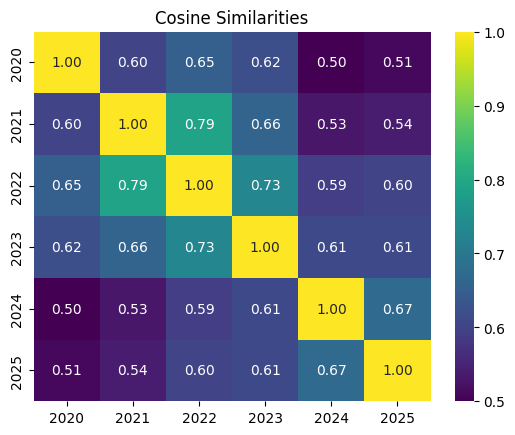

In [ ]:
sims_df = pd.DataFrame(cosine_sims).rename(columns={0:2020, 1:2021, 2:2022, 3:2023, 4:2024, 5:2025})
sims_df.index = possible_years

heatmap = sns.heatmap(sims_df, annot=True, fmt=".2f", cmap="viridis")
heatmap.set_title("Cosine Similarities");

in general, more distant years have lower cosine similarities in their buzzwords

### permuation test

null hypothesis: overlap between buzzwords is random

alt hypothesis: overlap between buzzwords is lower than expected

get a random sample of 100 words from global vocab set, compute cosine similarities n times, and see how often the observed cosine similarities occur

In [ ]:
import random

global_vocab = set()

for year in possible_years:
    global_vocab = global_vocab | top_words_by_year.get(year)

year_null_cosine_sims = {}

for year in possible_years:
    null_cosine_sims = []
    year_words = top_words_by_year.get(year)

    for _ in range(10000):
        sample = set(random.sample(sorted(global_vocab), 100))

        null_cosine_sim = cosine_similarity(year_words, sample)
        null_cosine_sims.append(null_cosine_sim)

    year_null_cosine_sims[year] = null_cosine_sims

In [ ]:
from itertools import combinations

year_combinations = list(combinations(possible_years, 2))
print(year_combinations)

[(np.int32(2020), np.int32(2021)), (np.int32(2020), np.int32(2022)), (np.int32(2020), np.int32(2023)), (np.int32(2020), np.int32(2024)), (np.int32(2020), np.int32(2025)), (np.int32(2021), np.int32(2022)), (np.int32(2021), np.int32(2023)), (np.int32(2021), np.int32(2024)), (np.int32(2021), np.int32(2025)), (np.int32(2022), np.int32(2023)), (np.int32(2022), np.int32(2024)), (np.int32(2022), np.int32(2025)), (np.int32(2023), np.int32(2024)), (np.int32(2023), np.int32(2025)), (np.int32(2024), np.int32(2025))]


In [ ]:
alpha = 0.05

for year1, year2 in year_combinations:
    cosine_sim = sims_df.loc[year1][year2]
    p_value = np.mean(np.array(year_null_cosine_sims.get(year1)) <= cosine_sim)
    
    if p_value < alpha:
        print(f"For years {year1} and {year2}, we reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is lower than expected.")
    else:
        print(f"For years {year1} and {year2}, we fail to reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is not lower than expected.")

For years 2020 and 2021, we fail to reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is not lower than expected.
For years 2020 and 2022, we fail to reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is not lower than expected.
For years 2020 and 2023, we fail to reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is not lower than expected.
For years 2020 and 2024, we fail to reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is not lower than expected.
For years 2020 and 2025, we fail to reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is not lower than expected.
For years 2021 and 2022, we fail to reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is not lower than expected.
For years 2021 and 2023, we fail to reject the

there is no statistically significant evidence that the cosine similarities between years are lower than expected; the buzzwords between years do not seem to clearly differ year by year

### permutation test 2

null hypothesis: overlap between buzzwords is random

alt hypothesis: overlap between buzzwords is higher than expected


In [128]:
alpha = 0.05

for year1, year2 in year_combinations:
    cosine_sim = sims_df.loc[year1][year2]
    p_value = np.mean(np.array(year_null_cosine_sims.get(year1)) >= cosine_sim)
    
    if p_value < alpha:
        print(f"For years {year1} and {year2}, we reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is higher than expected.")
    else:
        print(f"For years {year1} and {year2}, we fail to reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is not higher than expected.")

For years 2020 and 2021, we reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is higher than expected.
For years 2020 and 2022, we reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is higher than expected.
For years 2020 and 2023, we reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is higher than expected.
For years 2020 and 2024, we fail to reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is not higher than expected.
For years 2020 and 2025, we reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is higher than expected.
For years 2021 and 2022, we reject the null hypothesis that the overlap between buzzwords is random. The cosine similarity is higher than expected.
For years 2021 and 2023, we reject the null hypothesis that the overlap between buzzwords is random.

there is statistically significant evidence that the buzzwords used in ads actually stay relatively similar across years

it seems that the similarity between 2020 and 2024 was possibly due to random chance